In [71]:
#the below is a test, using the first line from the dataset
lines = open("../data/3I_ATLAS_obs.txt").read().splitlines()
print(len(lines)) #prints the number of lines (starting at 0)

8433


In [72]:
line0 = lines[0]
print(repr(line0)) #The raw line
print("line0 date: ", line0[15:32]) #the date for this line, with the lower number essentially shifted, as python reads differently than humans
print("line0 ra: ", line0[32:44]) #the right ascencion for this line
print("line0 dec: ", line0[44:56]) #the declination for this line
print("line0 obs: ", line0[77:80]) #info abt the observer for this line

'\u200b0003I         S2025 05 08.51765919 12 35.590-18 42 21.35         21.57VV#0K4XC57'
line0 date:  S2025 05 08.51765
line0 ra:  919 12 35.59
line0 dec:  0-18 42 21.3
line0 obs:  XC5


In [73]:
import pandas as pd

rows = []
skipped = 0 #this creates a counter for lines we couldn't parse
skipped_pair = 0
for line0 in lines:
    if line0[14].islower(): #any lowercase letter
        skipped_pair += 1
        continue

    #the below is a fix to make the parser detect if there is a shift from an S at the start of the date, from if the observer was a space telescope. This should fix that error.
    off = 0 if line0[15].isdigit() else 1
    rows.append({ #builds a list for the current line of all of its important info (normalizes data)
        "date_str": line0[15+off:32+off].strip(),
        "ra_str":   line0[32+off:44+off].strip(),
        "dec_str":  line0[44+off:56+off].strip(),
        "obscode":  line0[77+off:80+off],
    })

df = pd.DataFrame(rows) #turns the list into a table
print(len(df), "parsed,", skipped, "skipped") #prints how many rows were skipped, and how many made it to the table
df.head() #shows the first five rows of the table

8348 parsed, 0 skipped


,date_str,ra_str,dec_str,obscode
0,2025 05 08.517659,19 12 35.590,-18 42 21.35,C57
1,2025 05 10.603515,19 11 27.094,-18 41 21.70,C57
2,2025 05 12.689361,19 10 11.775,-18 40 49.56,C57
3,2025 05 14.990495,19 08 42.571,-18 40 42.61,C57
4,2025 05 15.421174,19 08 28.246,-18 41 39.48,I41


In [74]:
#This is a validator cell, to ensure that every weird line gets caught before going to the next few cells
looks_ok = df["ra_str"].str.match(r"^\d{2} \d{2} \d{2}") #this line tests every entry in the ra_str column against a pattern, only passing lines that pass the pattern, testing each invididual row. The pattern itself checks to ensure that starting at the very beginning of the string, there are exactly 3 pairs of two digits seperated by spaces.
print((~looks_ok).sum(), "suspicious rows") #the ~ means not, and flips every true to false and visa versa, so looks ok then marks the rows that failed the test, so we know how many failed without creating a new variable. .sum simply counts how many of these failures there are, and the print tells me the quantity
df[~looks_ok].head() #This line prints out the first five rows that didn't pass the test.

0 suspicious rows


,date_str,ra_str,dec_str,obscode


In [75]:
#This column will turn the RA and the Dec into degrees, so they're usable for plotting this data
from astropy.coordinates import SkyCoord #pulls in skyCoord, which is a tool astropy has for representing sky positions
import astropy.units as u #pulling in astropy's system for units (degrees, hours, etc.)

coords = SkyCoord(df["ra_str"], df["dec_str"], unit=(u.hourangle, u.deg)) #feeds the entire RA and Dec columns to SkyCoord at once, and the unit tells it that RA text is in the format of hours-minutes-seconds, while Dec text is in the format of degrees-minutes-seconds
df["ra_deg"] = coords.ra.deg #Creates a new column labeled ra_deg in my table, that contains each RA value now as degrees
df["dec_deg"] = coords.dec.deg #Creates a new column labeled dec_deg in my table, that contains each Dec value now as degrees
df.head() #prints the first five rows, to view the new columns 

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg
0,2025 05 08.517659,19 12 35.590,-18 42 21.35,C57,288.148292,-18.705931
1,2025 05 10.603515,19 11 27.094,-18 41 21.70,C57,287.862892,-18.689361
2,2025 05 12.689361,19 10 11.775,-18 40 49.56,C57,287.549062,-18.680433
3,2025 05 14.990495,19 08 42.571,-18 40 42.61,C57,287.177379,-18.678503
4,2025 05 15.421174,19 08 28.246,-18 41 39.48,I41,287.117692,-18.694300


In [76]:
#this cell should convert the date text into readible simestamps
from datetime import datetime, timedelta #uses python's built in date tools. datetime is for a moment in time, and time delta is for an amount of time

def parse_date(s): #creates a program called parse_date that takes a text date and returns a timestamp
    y, m, d = s.split() #splits our text into three peices, year, m onth, and day (fraction of a day)
    day_frac = float(d) #converts the text for the day (ex. 08.51765) into a number
    day = int(day_frac) #keeps the whole number part, and seperates the fraction
    frac = day_frac - day #converts the leftover decimal into the fraction of the day that had passed (ex. 0.41196 to abt 9.9 hrs)
    return datetime(int(y), int(m), day) + timedelta(days=frac) #adds the fraction as actual hours.minutes, returns the completed timestamp

df["time"] = df["date_str"].apply(parse_date) # runs the program on every entry within the date_str column in the dataset, and stores the results in a new column it created, time.
df.head() #prints the timestamps for the first 5 rows of the dataset

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg,time
0,2025 05 08.517659,19 12 35.590,-18 42 21.35,C57,288.148292,-18.705931,2025-05-08 12:25:25.737600
1,2025 05 10.603515,19 11 27.094,-18 41 21.70,C57,287.862892,-18.689361,2025-05-10 14:29:03.696000
2,2025 05 12.689361,19 10 11.775,-18 40 49.56,C57,287.549062,-18.680433,2025-05-12 16:32:40.790400
3,2025 05 14.990495,19 08 42.571,-18 40 42.61,C57,287.177379,-18.678503,2025-05-14 23:46:18.768000
4,2025 05 15.421174,19 08 28.246,-18 41 39.48,I41,287.117692,-18.694300,2025-05-15 10:06:29.433600


In [77]:
#This cell should administer sanity checks
print("total observations:", len(df)) #len(df) is the number of rows on our table, equilivent to the observations parsed
print("first:", df["time"].min()) #prints out the earliest timesteamp in the time column
print("last: ", df["time"].max()) #prints out the latest timestamp in the time column
print(df["obscode"].value_counts().head(10)) #counts how many times each different observatory code appears, sorted from largest to smallest, and shows the top 10

total observations: 8348
first: 2025-05-08 12:25:25.737600
last:  2026-04-14 23:21:21.801600
obscode
C40    245
C23    234
W68    213
T05    207
213    172
958    140
W84    137
323    122
R17    111
R59    110
Name: count, dtype: int64


In [78]:
#quantifies the entries from TESS
sat = df[df["obscode"] == "C57"]
print(len(sat), sat["time"].min())

15 2025-05-08 12:25:25.737600


In [79]:
#This cell sorts our table by time, preparing it for being graphed.
df = df.sort_values("time")
df.tail(3)

,date_str,ra_str,dec_str,obscode,ra_deg,dec_deg,time
8345,2026 04 14.938546,06 45 05.106,+20 28 50.79,R59,101.271275,20.480775,2026-04-14 22:31:30.374400
8346,2026 04 14.956385,06 45 05.215,+20 28 50.82,R59,101.271729,20.480783,2026-04-14 22:57:11.664000
8347,2026 04 14.973169,06 45 05.179,+20 28 50.38,R59,101.271579,20.480661,2026-04-14 23:21:21.801600


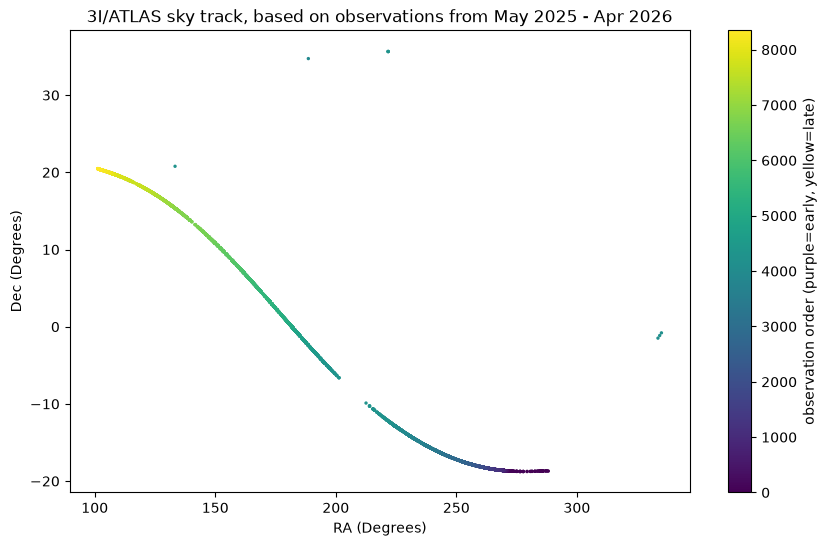

In [82]:
#This will create a plot of the skytrack of 3I/ATLAS throughout all of its available observations
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) #Creates a new blank figure/plot, 10x6 inches
plt.scatter(df["ra_deg"], df["dec_deg"], c=range(len(df)), cmap="viridis", s=2) #The actual scatter plot is created here. c=range(len(df)) colors dots by row number, so color = time, as df was sorted by time. cmap="viridis" is a purple-to-yellow color scale, so our datapoint colors will range from purple to yellow, and s=2 makes these dots very small
plt.colorbar(label="observation order (purple=early, yellow=late)") #adds the color legend so that you can actually understand how it relates to time
plt.xlabel("RA (Degrees)") #Label for the x-axis
plt.ylabel("Dec (Degrees)") #Label for the y-axis
import os
os.makedirs("../figures", exist_ok=True)
plt.title("3I/ATLAS sky track, based on observations from May 2025 - Apr 2026") #Titel for the plot
plt.savefig("../figures/3I_Atlas_skypath_v1.png", dpi=150) #saves this to my computer as a png file
plt.show()